In [64]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans



In [14]:
df = pd.read_csv("../data/data.csv",encoding="Latin-1")

In [5]:
df.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  541909 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   541909 non-null  object 
 7   Country      541909 non-null  object 
dtypes: float64(1), int64(1), object(6)
memory usage: 33.1+ MB


In [41]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalPrice     0
dtype: int64

In [23]:
df['CustomerID'] = df['CustomerID'].astype(str)

In [ ]:
df['CustomerID'] = df['CustomerID'].dropna()

In [18]:
df['Description'] = df['Description'].fillna(df['Description'].mode()[0])

In [28]:
df.describe()

,Quantity,UnitPrice
count,541909.000000,541909.000000
mean,9.552250,4.611114
std,218.081158,96.759853
min,-80995.000000,-11062.060000
25%,1.000000,1.250000
50%,3.000000,2.080000
75%,10.000000,4.130000
max,80995.000000,38970.000000


In [29]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [30]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [ ]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
snapshot_date   

Timestamp('2011-12-10 12:50:00')

In [57]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

In [58]:
rfm.columns = ['Recency', 'Frequency', 'Monetary'] 

In [53]:
df['CustomerID'] = df['CustomerID'].astype(float)

In [59]:
rfm.sort_values(by='Monetary', ascending=False).head()

,Recency,Frequency,Monetary
CustomerID,,,
14646.0,2,77,279489.02
18102.0,1,62,256438.49
17450.0,8,55,187482.17
14911.0,1,248,132572.62
12415.0,24,26,123725.45


In [60]:
rfm.index.isnull().sum()

np.int64(0)

In [63]:

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

In [65]:

wcss = []

for i in range(1, 10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

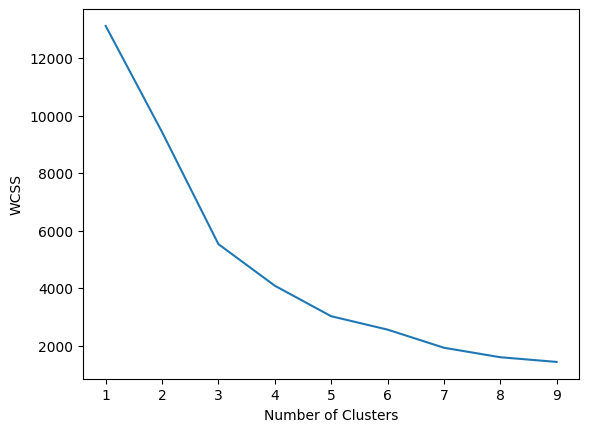

In [66]:

plt.plot(range(1,10), wcss)
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [67]:
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [ ]:
rfm

Recency       402430.000
Frequency      22190.000
Monetary     8300065.814
Cluster        10369.000
dtype: float64

In [69]:
rfm.groupby('Cluster').mean()

,Recency,Frequency,Monetary
Cluster,,,
0,10.752577,28.510309,12168.264691
1,248.927577,1.805942,455.110716
2,5.090909,109.909091,124312.306364
3,42.780906,4.370550,1320.981506


In [72]:
def segment_customer(row):
    if row['Cluster'] == 0:
        return 'VIP'
    elif row['Cluster'] == 1:
        return 'At Risk'
    elif row['Cluster'] == 2:
        return 'Regular'
    else:
        return 'New'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

In [74]:
rfm['Segment'].value_counts()

Segment
New        3090
At Risk    1077
VIP         194
Regular      11
Name: count, dtype: int64

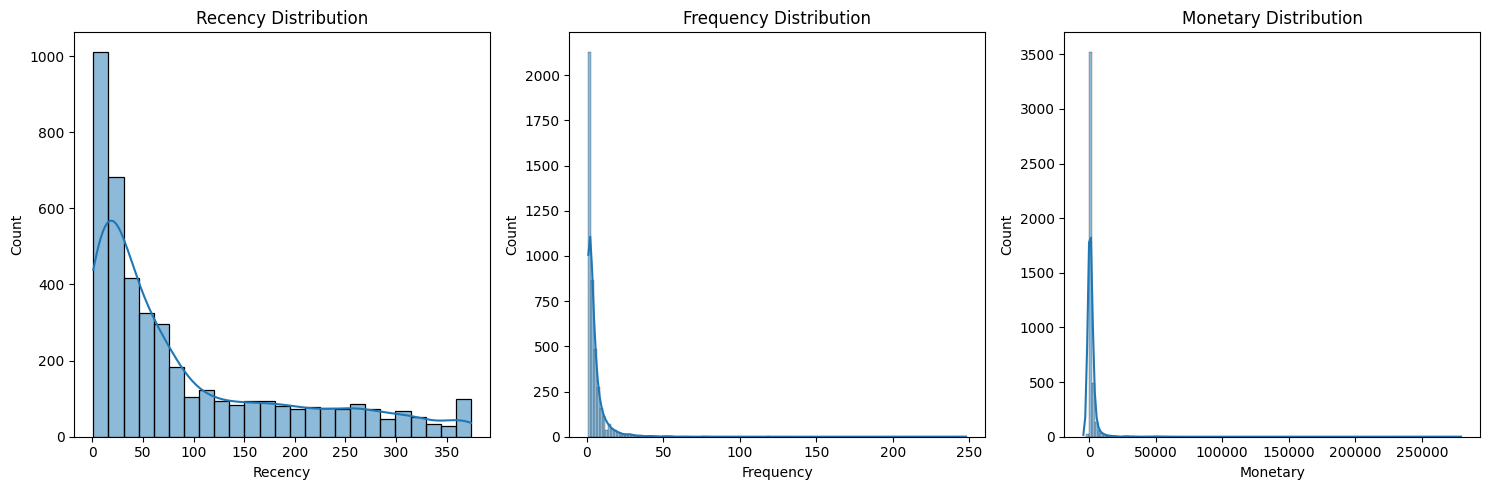

In [82]:

fig, axes = plt.subplots(1, 3, figsize=(15,5))

sns.histplot(rfm['Recency'], ax=axes[0], kde=True)
axes[0].set_title('Recency Distribution')

sns.histplot(rfm['Frequency'], ax=axes[1], kde=True)
axes[1].set_title('Frequency Distribution')

sns.histplot(rfm['Monetary'], ax=axes[2], kde=True)
axes[2].set_title('Monetary Distribution')

plt.tight_layout()
plt.show()

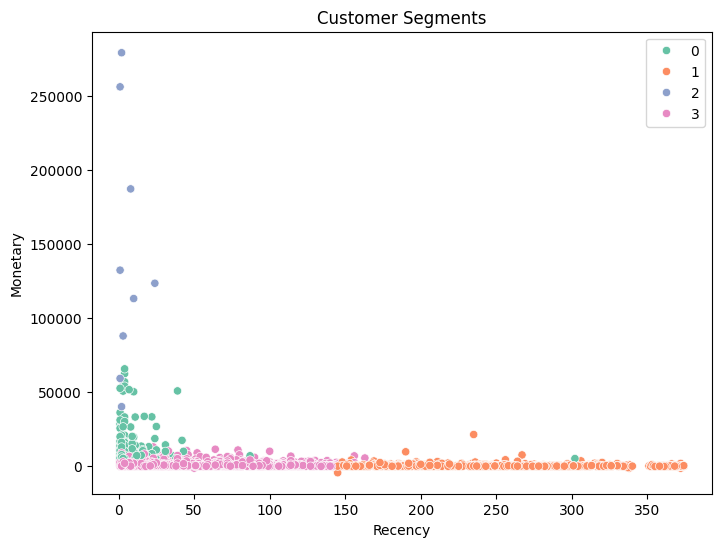

In [77]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=rfm['Recency'],
    y=rfm['Monetary'],
    hue=rfm['Cluster'],
    palette='Set2'
)

plt.title('Customer Segments')
plt.xlabel('Recency')
plt.ylabel('Monetary')
plt.legend()
plt.show()

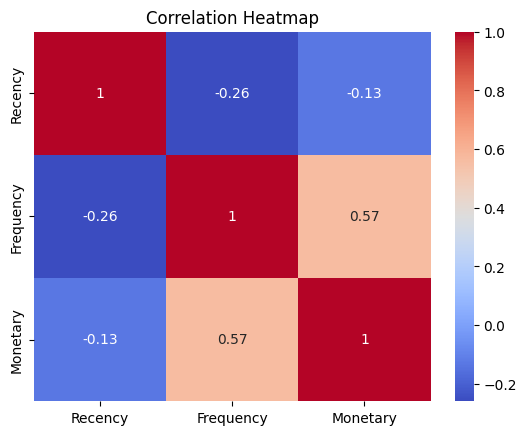

In [79]:
sns.heatmap(rfm[['Recency','Frequency','Monetary']].corr(),
            annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap')
plt.show()

Text(0.5, 1.0, 'Monetary Distribution')